# Credit Score Predictor

**DATASET:** Bank Customers

**EN — Goal:** Analyze the data and gain insights by building a machine learning model capable of accurately predicting the credit score of future clients.

**ES — Objetivo:** Analizar los datos y obtener información construyendo un modelo de machine learning capaz de predecir con precisión el credit score de futuros clientes.

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt

from scipy import stats

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score


## Loading the Original Dataset / Carga del Dataset Original

In [2]:
df= pd.read_csv('data/credit_data.csv')
df

,active_member,employment_profile,gender,age,income,credit_history,existing_loans,loan_amount,loan_tenure_months,LTV_ratio,profile_score,Credit_Score
0,No,Salaried,Male,31,36000,487,5,109373,221,90.943430,77,604
1,No,Salaried,Male,25,50000,386,2,150000,89,91.135253,43,447
2,Yes,Salaried,Other,62,178000,503,10,69099,110,40.000000,90,850
3,Yes,Self-Employed,Female,69,46000,349,6,150000,148,87.393365,86,668
4,No,Salaried,Male,52,132000,553,5,150000,157,66.158757,90,601
...,...,...,...,...,...,...,...,...,...,...,...,...
279851,No,Salaried,Male,69,61000,565,3,150000,14,90.300189,71,495
279852,Yes,Salaried,Female,45,124000,476,10,80341,86,78.960607,91,850
279853,No,Unemployed,Female,33,71000,560,5,39851,101,95.000000,57,582
279854,No,Salaried,Male,67,191000,481,2,150000,111,56.109002,69,411


## Description of Variables / Descripción de las Variables

**EN**

* Categorical variables: `employment_profile` shows if the customer is salaried, self-employed, a freelancer, or unemployed; `gender` identifies if the customer is male, female, or other.

* Numerical variables: `age` represents the customer’s age; `income` shows the customer’s income; `credit_history` reflects their credit history; `existing_loans` is the number of active loans; `loan_amount` is the total amount owed; `loan_tenure_months` indicates how many months the customer has had debts; `LTV_ratio` (loan-to-value ratio) measures the proportion between the loan amount and the value of the collateral property; `profile_score` is the overall profile rating; and `credit_score` is a value between 350 and 850 indicating creditworthiness.

* Binary variable: `active_member` shows whether the customer is currently an active bank member.

---

**ES**

* Variables categóricas: `employment_profile` indica si el cliente es asalariado, independiente, freelancer o desempleado; `gender` identifica si el cliente es hombre, mujer u otro.

* Variables numéricas: `age` representa la edad del cliente; `income` muestra el ingreso del cliente; `credit_history` refleja su historial crediticio; `existing_loans` es el número de préstamos activos; `loan_amount` es el monto total adeudado; `loan_tenure_months` indica cuántos meses lleva el cliente con deudas; `LTV_ratio` (relación préstamo-valor) mide la proporción entre el monto del préstamo y el valor de la garantía; `profile_score` es la calificación general del perfil; y `credit_score` es un valor entre 350 y 850 que indica la solvencia crediticia.

* Variable binaria: `active_member` indica si el cliente es actualmente un miembro activo del banco.

## Data Cleaning / Limpieza de Datos

In [3]:
# Check for NaN values and remove them / Revisar valores NaN y eliminarlos

print(df.isna().sum())

active_member         0
employment_profile    0
gender                0
age                   0
income                0
credit_history        0
existing_loans        0
loan_amount           0
loan_tenure_months    0
LTV_ratio             0
profile_score         0
Credit_Score          0
dtype: int64


In [4]:
# Removing NaNs — there’s only one row with missing values, so it’s safe to drop / Eliminando NaNs — solo hay una fila con valores faltantes, así que es seguro eliminarla

df = df.dropna()
print(df.isna().sum())

active_member         0
employment_profile    0
gender                0
age                   0
income                0
credit_history        0
existing_loans        0
loan_amount           0
loan_tenure_months    0
LTV_ratio             0
profile_score         0
Credit_Score          0
dtype: int64


In [5]:
# Check data types / Revisar tipos de datos

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 279856 entries, 0 to 279855
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   active_member       279856 non-null  str    
 1   employment_profile  279856 non-null  str    
 2   gender              279856 non-null  str    
 3   age                 279856 non-null  int64  
 4   income              279856 non-null  int64  
 5   credit_history      279856 non-null  int64  
 6   existing_loans      279856 non-null  int64  
 7   loan_amount         279856 non-null  int64  
 8   loan_tenure_months  279856 non-null  int64  
 9   LTV_ratio           279856 non-null  float64
 10  profile_score       279856 non-null  int64  
 11  Credit_Score        279856 non-null  int64  
dtypes: float64(1), int64(8), str(3)
memory usage: 25.6 MB


In [6]:
# Data types to be used / Tipos de datos a utilizar

df['active_member'].replace('No',False,inplace=True)
df['active_member'].replace('Yes',True,inplace=True)

df = df.astype({'active_member':'bool',
                'employment_profile':'category',
                'gender':'category'})

/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25514/1330722993.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['active_member'].replace('No',False,inplace=True)
/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25514/1330722993.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or

In [7]:
# Check data types / Revisar tipos de datos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 279856 entries, 0 to 279855
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype   
---  ------              --------------   -----   
 0   active_member       279856 non-null  bool    
 1   employment_profile  279856 non-null  category
 2   gender              279856 non-null  category
 3   age                 279856 non-null  int64   
 4   income              279856 non-null  int64   
 5   credit_history      279856 non-null  int64   
 6   existing_loans      279856 non-null  int64   
 7   loan_amount         279856 non-null  int64   
 8   loan_tenure_months  279856 non-null  int64   
 9   LTV_ratio           279856 non-null  float64 
 10  profile_score       279856 non-null  int64   
 11  Credit_Score        279856 non-null  int64   
dtypes: bool(1), category(2), float64(1), int64(8)
memory usage: 20.0 MB


In [8]:
# Unique values per column / Valores únicos por columna

columnas = df.columns

for x in columnas:
  print(df[x].unique())

[ True]
['Salaried', 'Self-Employed', 'Freelancer', 'Student', 'Unemployed']
Categories (5, str): ['Freelancer', 'Salaried', 'Self-Employed', 'Student', 'Unemployed']
['Male', 'Other', 'Female']
Categories (3, str): ['Female', 'Male', 'Other']
[31 25 62 69 52 64 29 30 39 68 19 59 26 57 42 34 20 56 37 61 54 24 23 53
 40 67 70 63 28 18 60 21 43 47 55 65 36 27 50 38 45 33 41 58 51 48 49 46
 22 44 66 35 32]
[ 36000  50000 178000  46000 132000 127000  15000  82000 119000 101000
 166000 167000  88000  25000  60000  53000 115000  44000  57000 149000
 147000  26000  68000 130000  41000  34000 116000  87000  37000  32000
  33000  20000 134000  72000  47000  65000  48000  16000  77000 110000
  92000  90000  28000  70000 192000  24000  63000  58000  29000  74000
  51000 128000  38000  79000  56000 118000 112000  94000  67000 103000
 162000 106000  31000  91000  66000 143000 135000 123000  89000  99000
 161000 122000  49000 105000  54000  19000  30000  98000 108000  78000
  97000  43000 121000 117

In [9]:
# Define integer values / Definir valores enteros

df = df.astype({'Credit_Score':'int',
                'profile_score':'int',
                'loan_tenure_months':'int',
                'loan_amount':'int',
                'existing_loans':'int',
                'credit_history':'int'})

In [10]:
# Final data types / Tipos de datos finales

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 279856 entries, 0 to 279855
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype   
---  ------              --------------   -----   
 0   active_member       279856 non-null  bool    
 1   employment_profile  279856 non-null  category
 2   gender              279856 non-null  category
 3   age                 279856 non-null  int64   
 4   income              279856 non-null  int64   
 5   credit_history      279856 non-null  int64   
 6   existing_loans      279856 non-null  int64   
 7   loan_amount         279856 non-null  int64   
 8   loan_tenure_months  279856 non-null  int64   
 9   LTV_ratio           279856 non-null  float64 
 10  profile_score       279856 non-null  int64   
 11  Credit_Score        279856 non-null  int64   
dtypes: bool(1), category(2), float64(1), int64(8)
memory usage: 20.0 MB


In [11]:
# Minimum and maximum credit scores / Puntajes de crédito mínimo y máximo

print(min(df['Credit_Score']))
print(max(df['Credit_Score']))

300
850


In [12]:
# Dataset ready for deeper exploration / Dataset listo para exploración más profunda

df

,active_member,employment_profile,gender,age,income,credit_history,existing_loans,loan_amount,loan_tenure_months,LTV_ratio,profile_score,Credit_Score
0,True,Salaried,Male,31,36000,487,5,109373,221,90.943430,77,604
1,True,Salaried,Male,25,50000,386,2,150000,89,91.135253,43,447
2,True,Salaried,Other,62,178000,503,10,69099,110,40.000000,90,850
3,True,Self-Employed,Female,69,46000,349,6,150000,148,87.393365,86,668
4,True,Salaried,Male,52,132000,553,5,150000,157,66.158757,90,601
...,...,...,...,...,...,...,...,...,...,...,...,...
279851,True,Salaried,Male,69,61000,565,3,150000,14,90.300189,71,495
279852,True,Salaried,Female,45,124000,476,10,80341,86,78.960607,91,850
279853,True,Unemployed,Female,33,71000,560,5,39851,101,95.000000,57,582
279854,True,Salaried,Male,67,191000,481,2,150000,111,56.109002,69,411


## Data Exploration / Exploración de Datos

In [13]:
# Measures of central tendency / Medidas de tendencia central

df.describe()

,age,income,credit_history,existing_loans,loan_amount,loan_tenure_months,LTV_ratio,profile_score,Credit_Score
count,279856.000000,279856.000000,279856.000000,279856.000000,279856.000000,279856.000000,279856.000000,279856.000000,279856.000000
mean,44.005217,76499.163856,307.965146,4.701693,105795.342773,133.340654,71.643101,77.350155,582.953773
std,15.311051,42875.575193,175.083268,2.980351,40458.370929,96.064132,16.865785,24.509196,163.076754
min,18.000000,9000.000000,6.000000,0.000000,5294.000000,12.000000,40.000000,0.000000,300.000000
25%,31.000000,42000.000000,156.000000,2.000000,72173.000000,62.000000,58.105848,61.000000,446.000000
50%,44.000000,68000.000000,307.000000,5.000000,111263.000000,100.000000,72.133017,89.000000,584.000000
75%,57.000000,104000.000000,460.000000,7.000000,150000.000000,201.000000,86.239725,98.000000,722.000000
max,70.000000,209000.000000,611.000000,10.000000,150000.000000,359.000000,95.000000,100.000000,850.000000


## Active Members / Miembros Activos

/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25514/21508627.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = df['active_member'], palette = "Set2", edgecolor = "black")


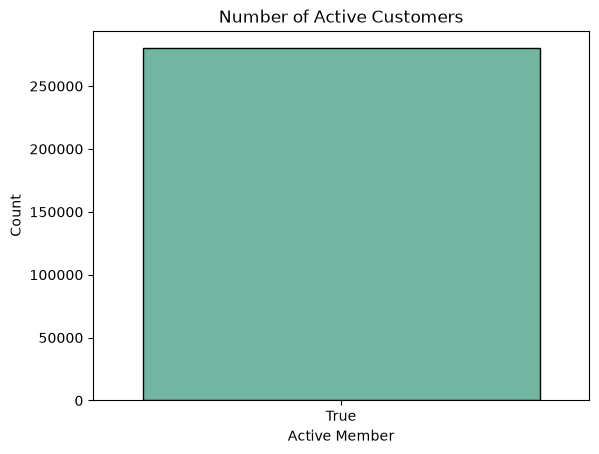

In [14]:
# Number of active clients / Número de clientes activos

ax = sns.countplot(x = df['active_member'], palette = "Set2", edgecolor = "black")
ax.set_title('Number of Active Customers')
ax.set(xlabel = 'Active Member')
ax.set(ylabel='Count')
plt.show()

## Employment Profile / Perfil Laboral

/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25514/2279106225.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = df['employment_profile'], palette = "Set2", edgecolor = "black")


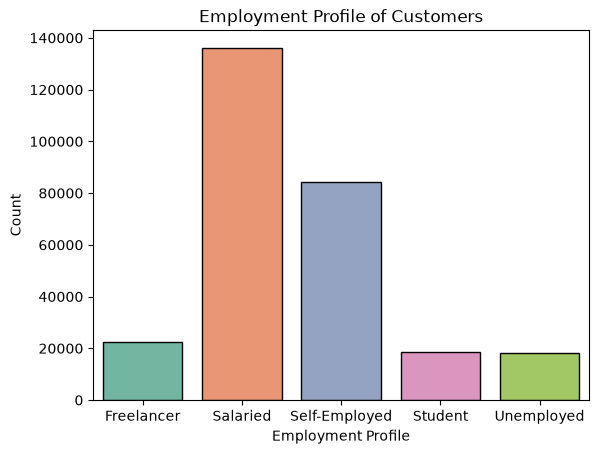

In [15]:
# Count of work profiles / Conteo de perfiles laborales

ax = sns.countplot(x = df['employment_profile'], palette = "Set2", edgecolor = "black")
ax.set_title('Employment Profile of Customers')
ax.set(xlabel = 'Employment Profile')
ax.set(ylabel='Count')
plt.show()

## Gender / Género

/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25514/3978743605.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data = df, x = df['gender'], palette = "Set2", edgecolor = "black")


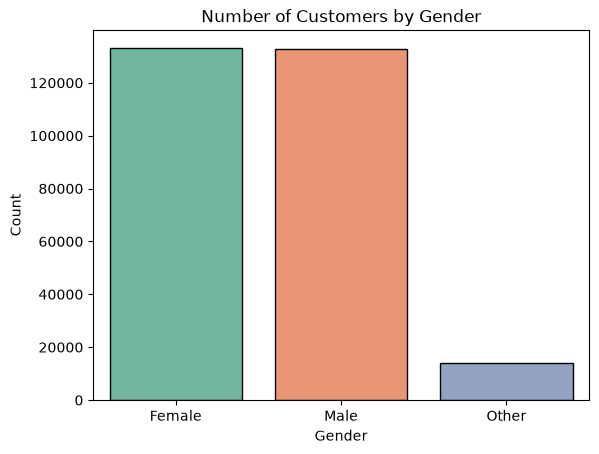

In [16]:
# Number of clients by gender / Número de clientes por género

ax = sns.countplot(data = df, x = df['gender'], palette = "Set2", edgecolor = "black")
ax.set_title('Number of Customers by Gender')
ax.set(xlabel = 'Gender')
ax.set(ylabel='Count')
plt.show()

## Age / Edad

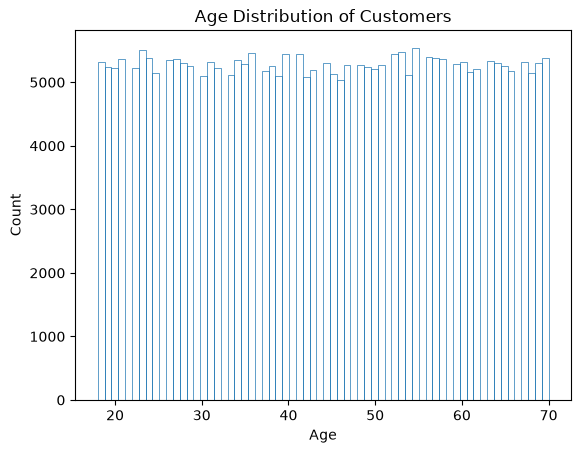

In [17]:
# Age distribution / Distribución de edad

ax = sns.histplot(x = df['age'], fill = False)
ax.set_title('Age Distribution of Customers')
ax.set(xlabel = 'Age')
ax.set(ylabel='Count')
plt.show()

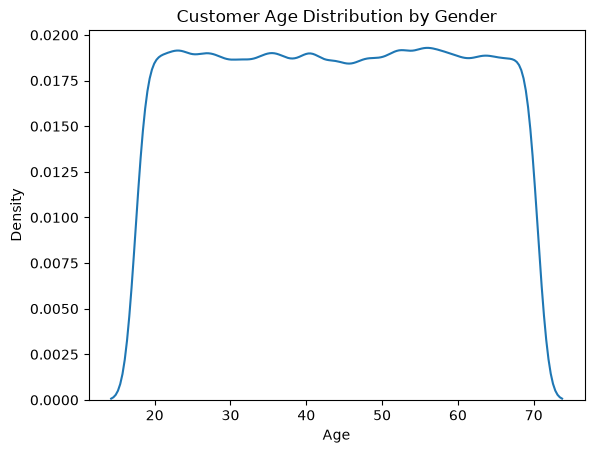

In [18]:
# Age distribution / Distribución de edad

ax = sns.kdeplot(data = df, x = df['age'])
ax.set_title('Customer Age Distribution by Gender')
ax.set(xlabel = 'Age')
ax.set(ylabel='Density')
plt.show()

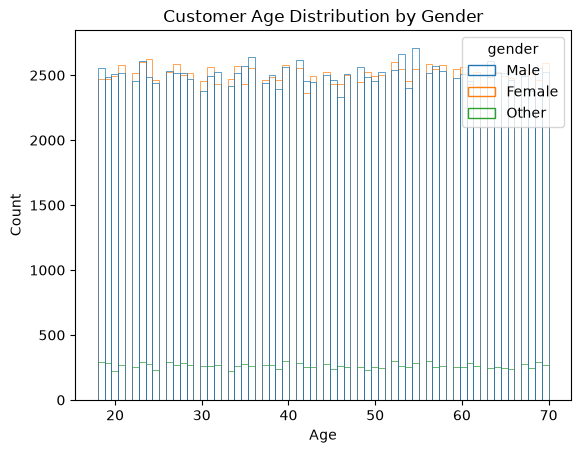

In [19]:
# Age and gender distribution / Distribución de edad y género

ax = sns.histplot(x = df['age'], hue = df['gender'], hue_order= ['Male','Female','Other'], fill = False)
ax.set_title('Customer Age Distribution by Gender')
ax.set(xlabel = 'Age')
ax.set(ylabel='Count')
plt.show()

/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25514/679202445.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df['age'] , palette = "Set2", ax=axes[0])
/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25514/679202445.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df['age'] , palette = "Set2", ax=axes[1])


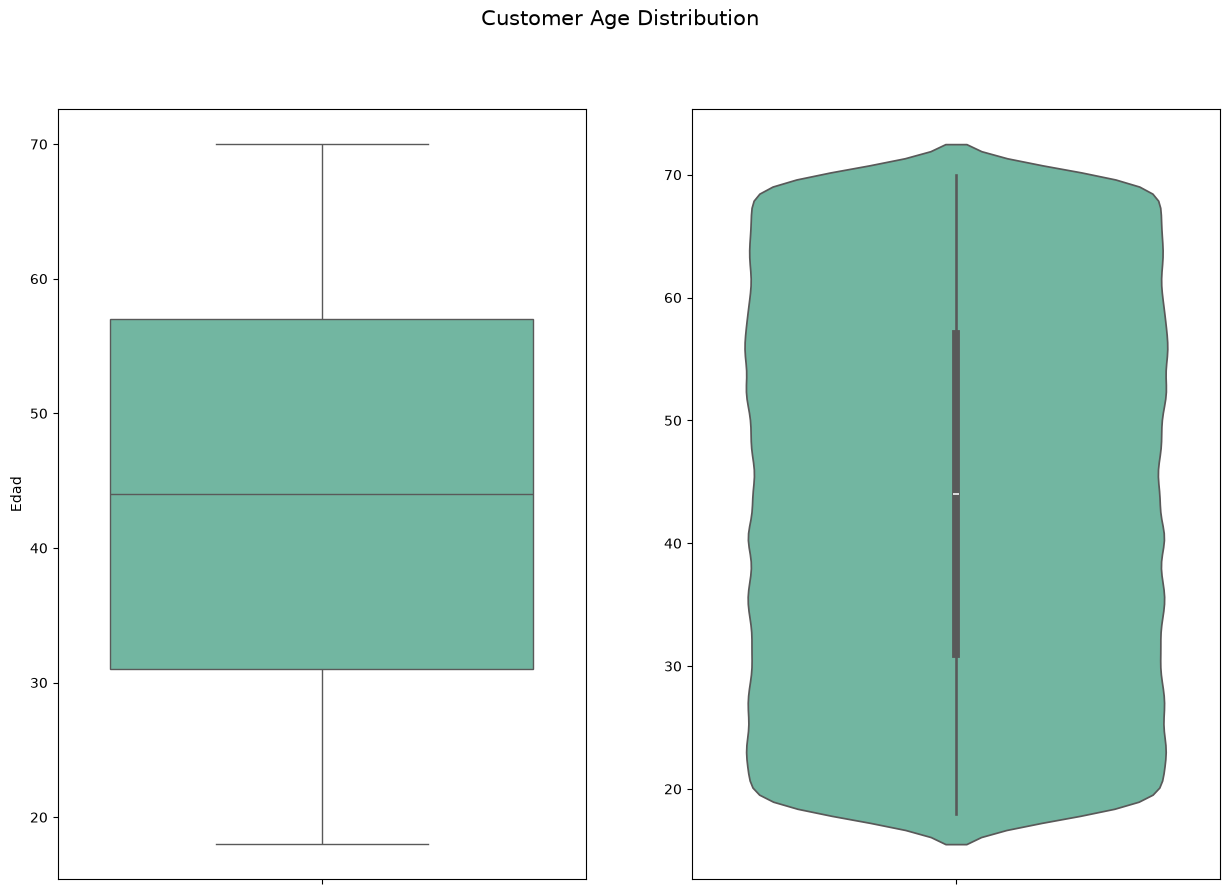

In [20]:
# Age distribution / Distribución de edad

fig, axes = plt.subplots(1, 2, figsize=(15, 10))

sns.boxplot(df['age'] , palette = "Set2", ax=axes[0])
sns.violinplot(df['age'] , palette = "Set2", ax=axes[1])


axes[0].set(xlabel='', ylabel='Edad', title='')
axes[1].set(xlabel='', ylabel='', title='')


fig.suptitle('Customer Age Distribution', fontsize=15)

plt.show()


## Income / Ingresos

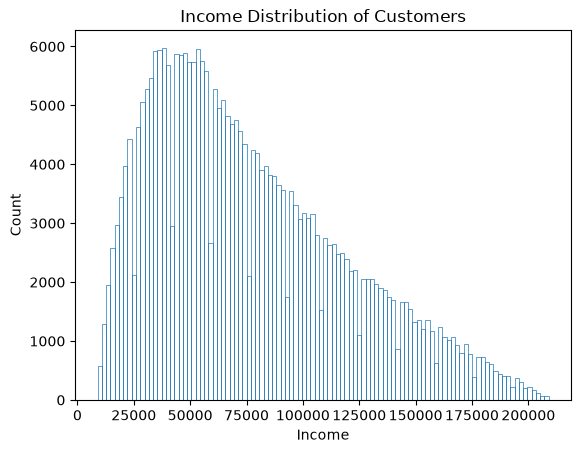

In [21]:
# Income distribution / Distribución de ingresos

ax = sns.histplot(x = df['income'], fill = False)
ax.set_title('Income Distribution of Customers')
ax.set(xlabel = 'Income')
ax.set(ylabel='Count')
plt.show()

/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25514/3459449189.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df['income'] , palette = "Set2", ax=axes[0])
/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25514/3459449189.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df['income'] , palette = "Set2", ax=axes[1])


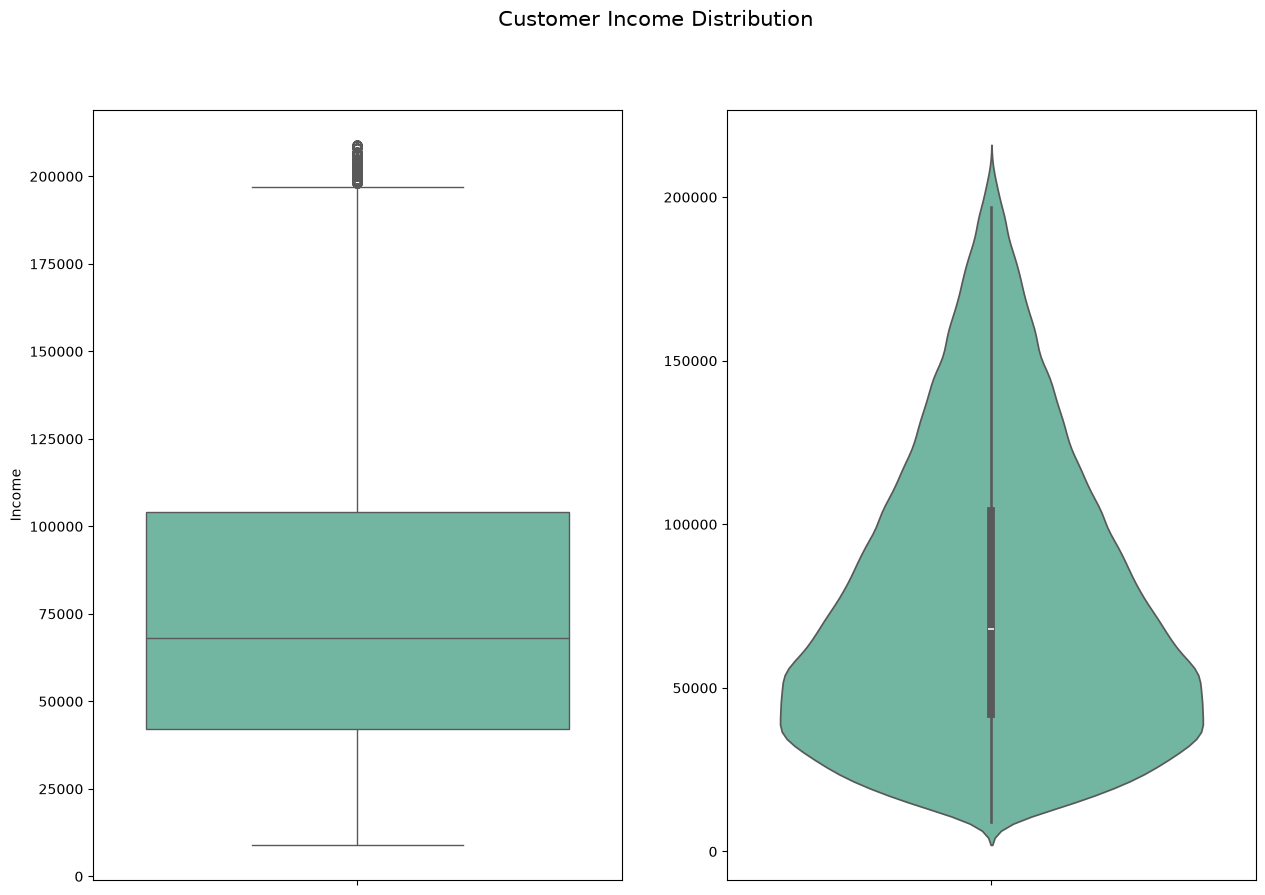

In [22]:
# Income distribution / Distribución de ingresos

fig, axes = plt.subplots(1, 2, figsize=(15, 10))

sns.boxplot(df['income'] , palette = "Set2", ax=axes[0])
sns.violinplot(df['income'] , palette = "Set2", ax=axes[1])


axes[0].set(xlabel='', ylabel='Income', title='')
axes[1].set(xlabel='', ylabel='', title='')


fig.suptitle('Customer Income Distribution', fontsize=15)

plt.show()


/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25514/3097504939.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x = df['gender'], y= df['income'],palette = "Set2")


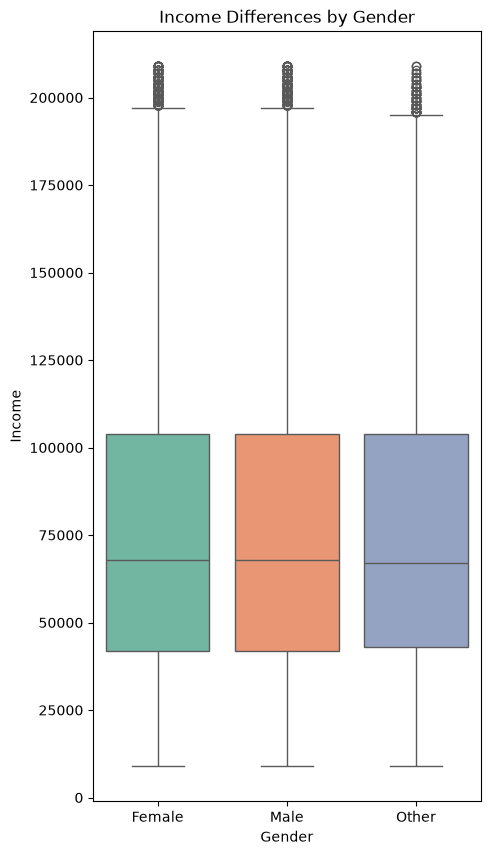

In [23]:
# Differences in income distribution between genders / Diferencias en la distribución de ingresos entre géneros

plt.figure(figsize=(5, 10))

ax = sns.boxplot(x = df['gender'], y= df['income'],palette = "Set2")
ax.set_title('Income Differences by Gender')
ax.set(ylabel = 'Income')
ax.set(xlabel = 'Gender')
plt.show()

## Credit History / Historial Crediticio

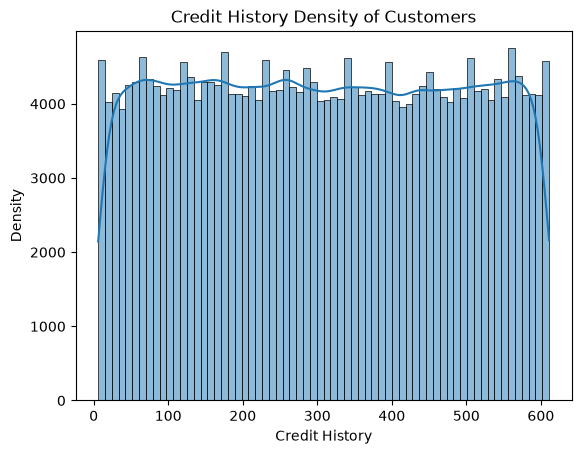

In [24]:
# Credit history distribution / Distribución del historial crediticio

ax = sns.histplot(x = df['credit_history'],kde=True)
ax.set_title('Credit History Density of Customers')
ax.set(xlabel = 'Credit History')
ax.set(ylabel='Density')
plt.show()

## Existing Loans / Préstamos Existentes

/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25514/726986815.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data = df, x = df['existing_loans'],edgecolor = "black",palette = "Set2")


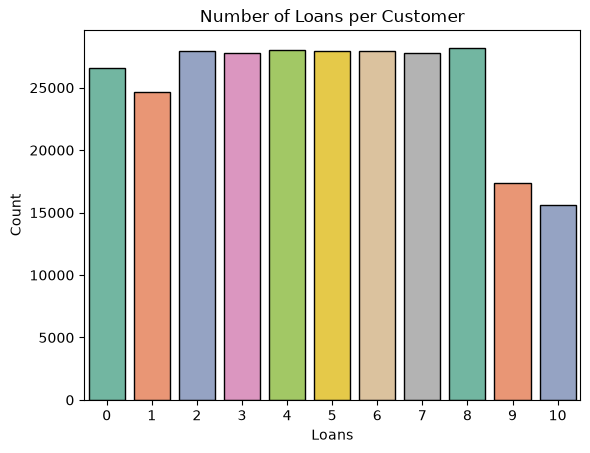

In [25]:
# Number of loans per customer / Número de préstamos por cliente

ax = sns.countplot(data = df, x = df['existing_loans'],edgecolor = "black",palette = "Set2")
ax.set_title('Number of Loans per Customer')
ax.set(xlabel = 'Loans')
ax.set(ylabel='Count')
plt.show()

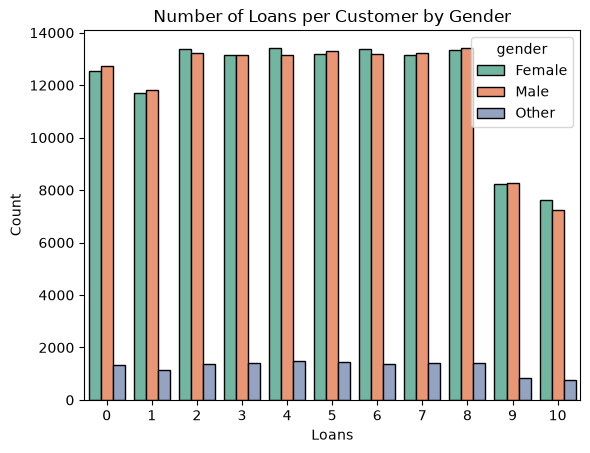

In [26]:
# Number of loans per customer by gender / Número de préstamos por cliente según género

ax = sns.countplot(data = df, x = df['existing_loans'],edgecolor = "black",palette = "Set2", hue = df['gender'])
ax.set_title('Number of Loans per Customer by Gender')
ax.set(xlabel = 'Loans')
ax.set(ylabel='Count')
plt.show()

## Loan Amount / Monto del Préstamo

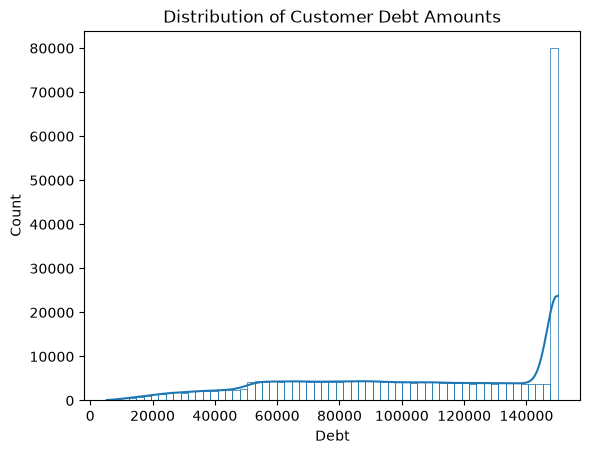

In [27]:
# Distribution of clients' debt amounts / Distribución de los montos de deuda de los clientes

ax = sns.histplot(x = df['loan_amount'],kde=True, fill = False)
ax.set_title('Distribution of Customer Debt Amounts')
ax.set(xlabel = 'Debt')
ax.set(ylabel='Count')
plt.show()

/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25514/1888809976.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df['loan_amount'] , palette = "Set2", ax=axes[0])
/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25514/1888809976.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df['loan_amount'] , palette = "Set2", ax=axes[1])


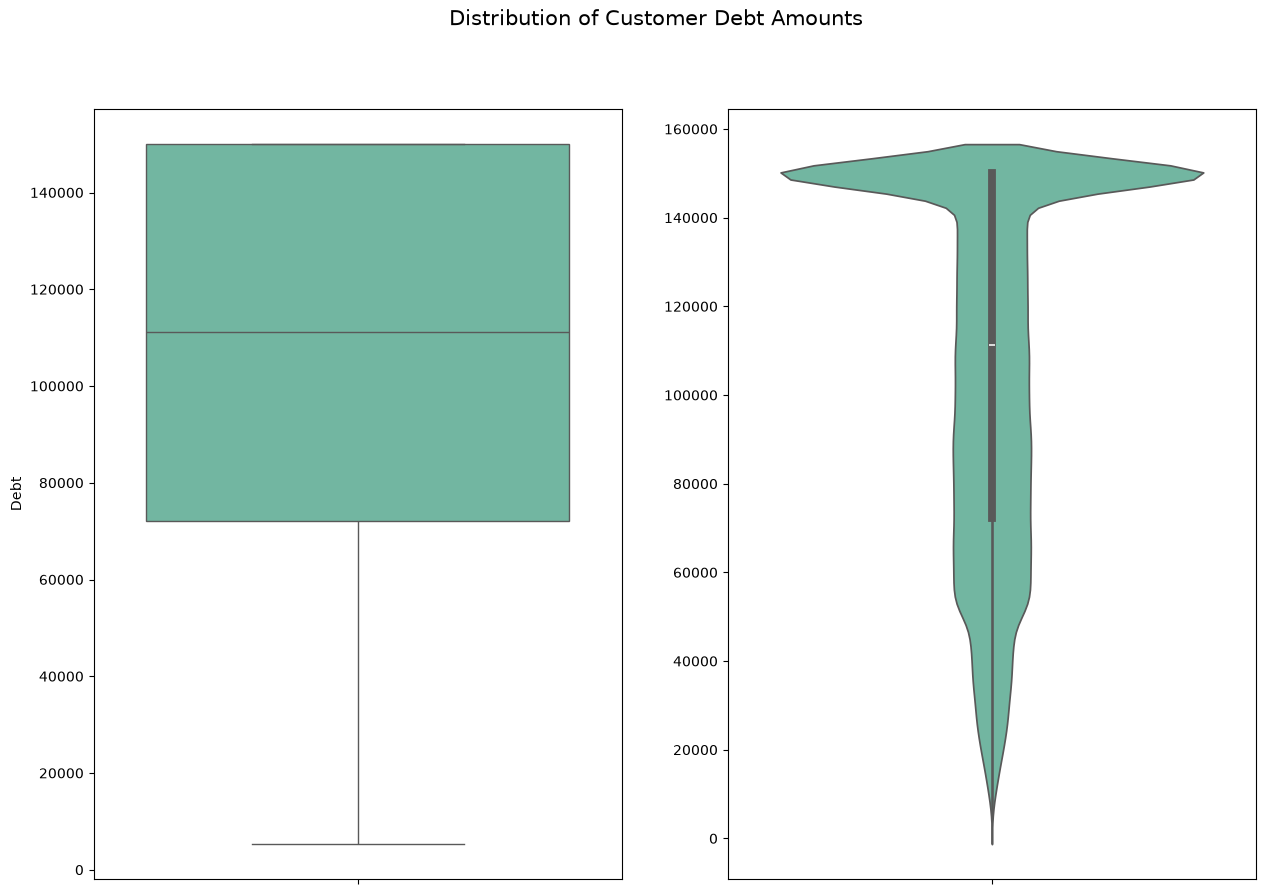

In [28]:
# Loan amount distribution / Distribución del monto del préstamo

fig, axes = plt.subplots(1, 2, figsize=(15, 10))

sns.boxplot(df['loan_amount'] , palette = "Set2", ax=axes[0])
sns.violinplot(df['loan_amount'] , palette = "Set2", ax=axes[1])


axes[0].set(xlabel='', ylabel='Debt', title='')
axes[1].set(xlabel='', ylabel='', title='')


fig.suptitle('Distribution of Customer Debt Amounts', fontsize=15)

plt.show()

## Loan Tenure in Months / Duración del Préstamo en Meses

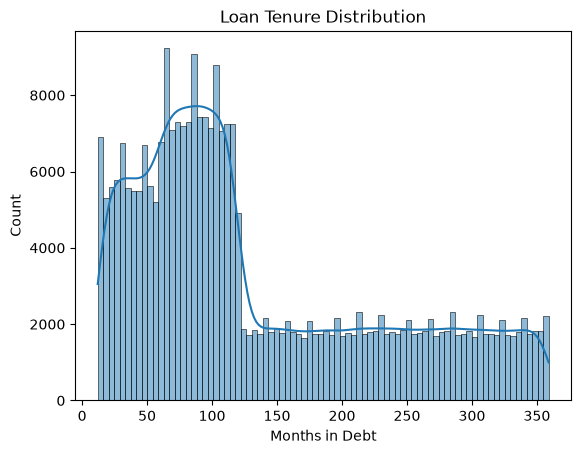

In [29]:
# Distribution of loan duration (in months) / Distribución de la duración del préstamo (en meses)

ax = sns.histplot(x = df['loan_tenure_months'],kde=True, fill = True)
ax.set_title('Loan Tenure Distribution')
ax.set(xlabel = 'Months in Debt')
ax.set(ylabel='Count')
plt.show()

## LTV Ratio / Profile Score / Credit Score (Puntaje de Crédito)

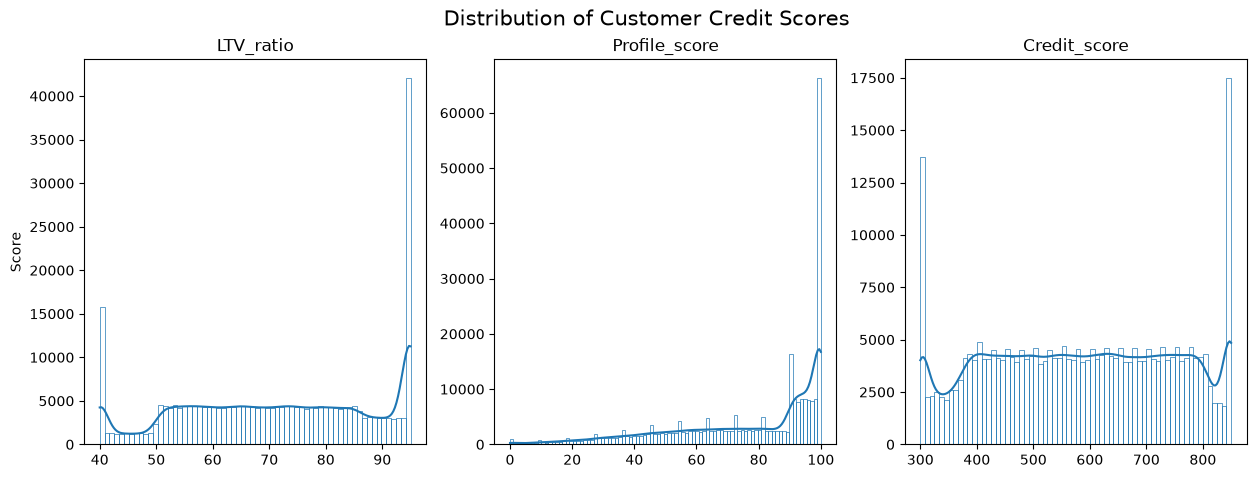

In [30]:
# Distribution of LTV ratio, profile score, and credit score / Distribución del LTV ratio, profile score y credit score

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df['LTV_ratio'] , kde=True, fill = False, ax=axes[0])
sns.histplot(df['profile_score'] , kde=True, fill = False, ax=axes[1])
sns.histplot(df['Credit_Score'] , kde=True, fill = False, ax=axes[2])

axes[0].set(xlabel='', ylabel='Score', title='LTV_ratio')
axes[1].set(xlabel='', ylabel='', title='Profile_score')
axes[2].set(xlabel='', ylabel='', title='Credit_score')

fig.suptitle('Distribution of Customer Credit Scores', fontsize=15)

plt.show()

## Correlation Analysis / Análisis de Correlación

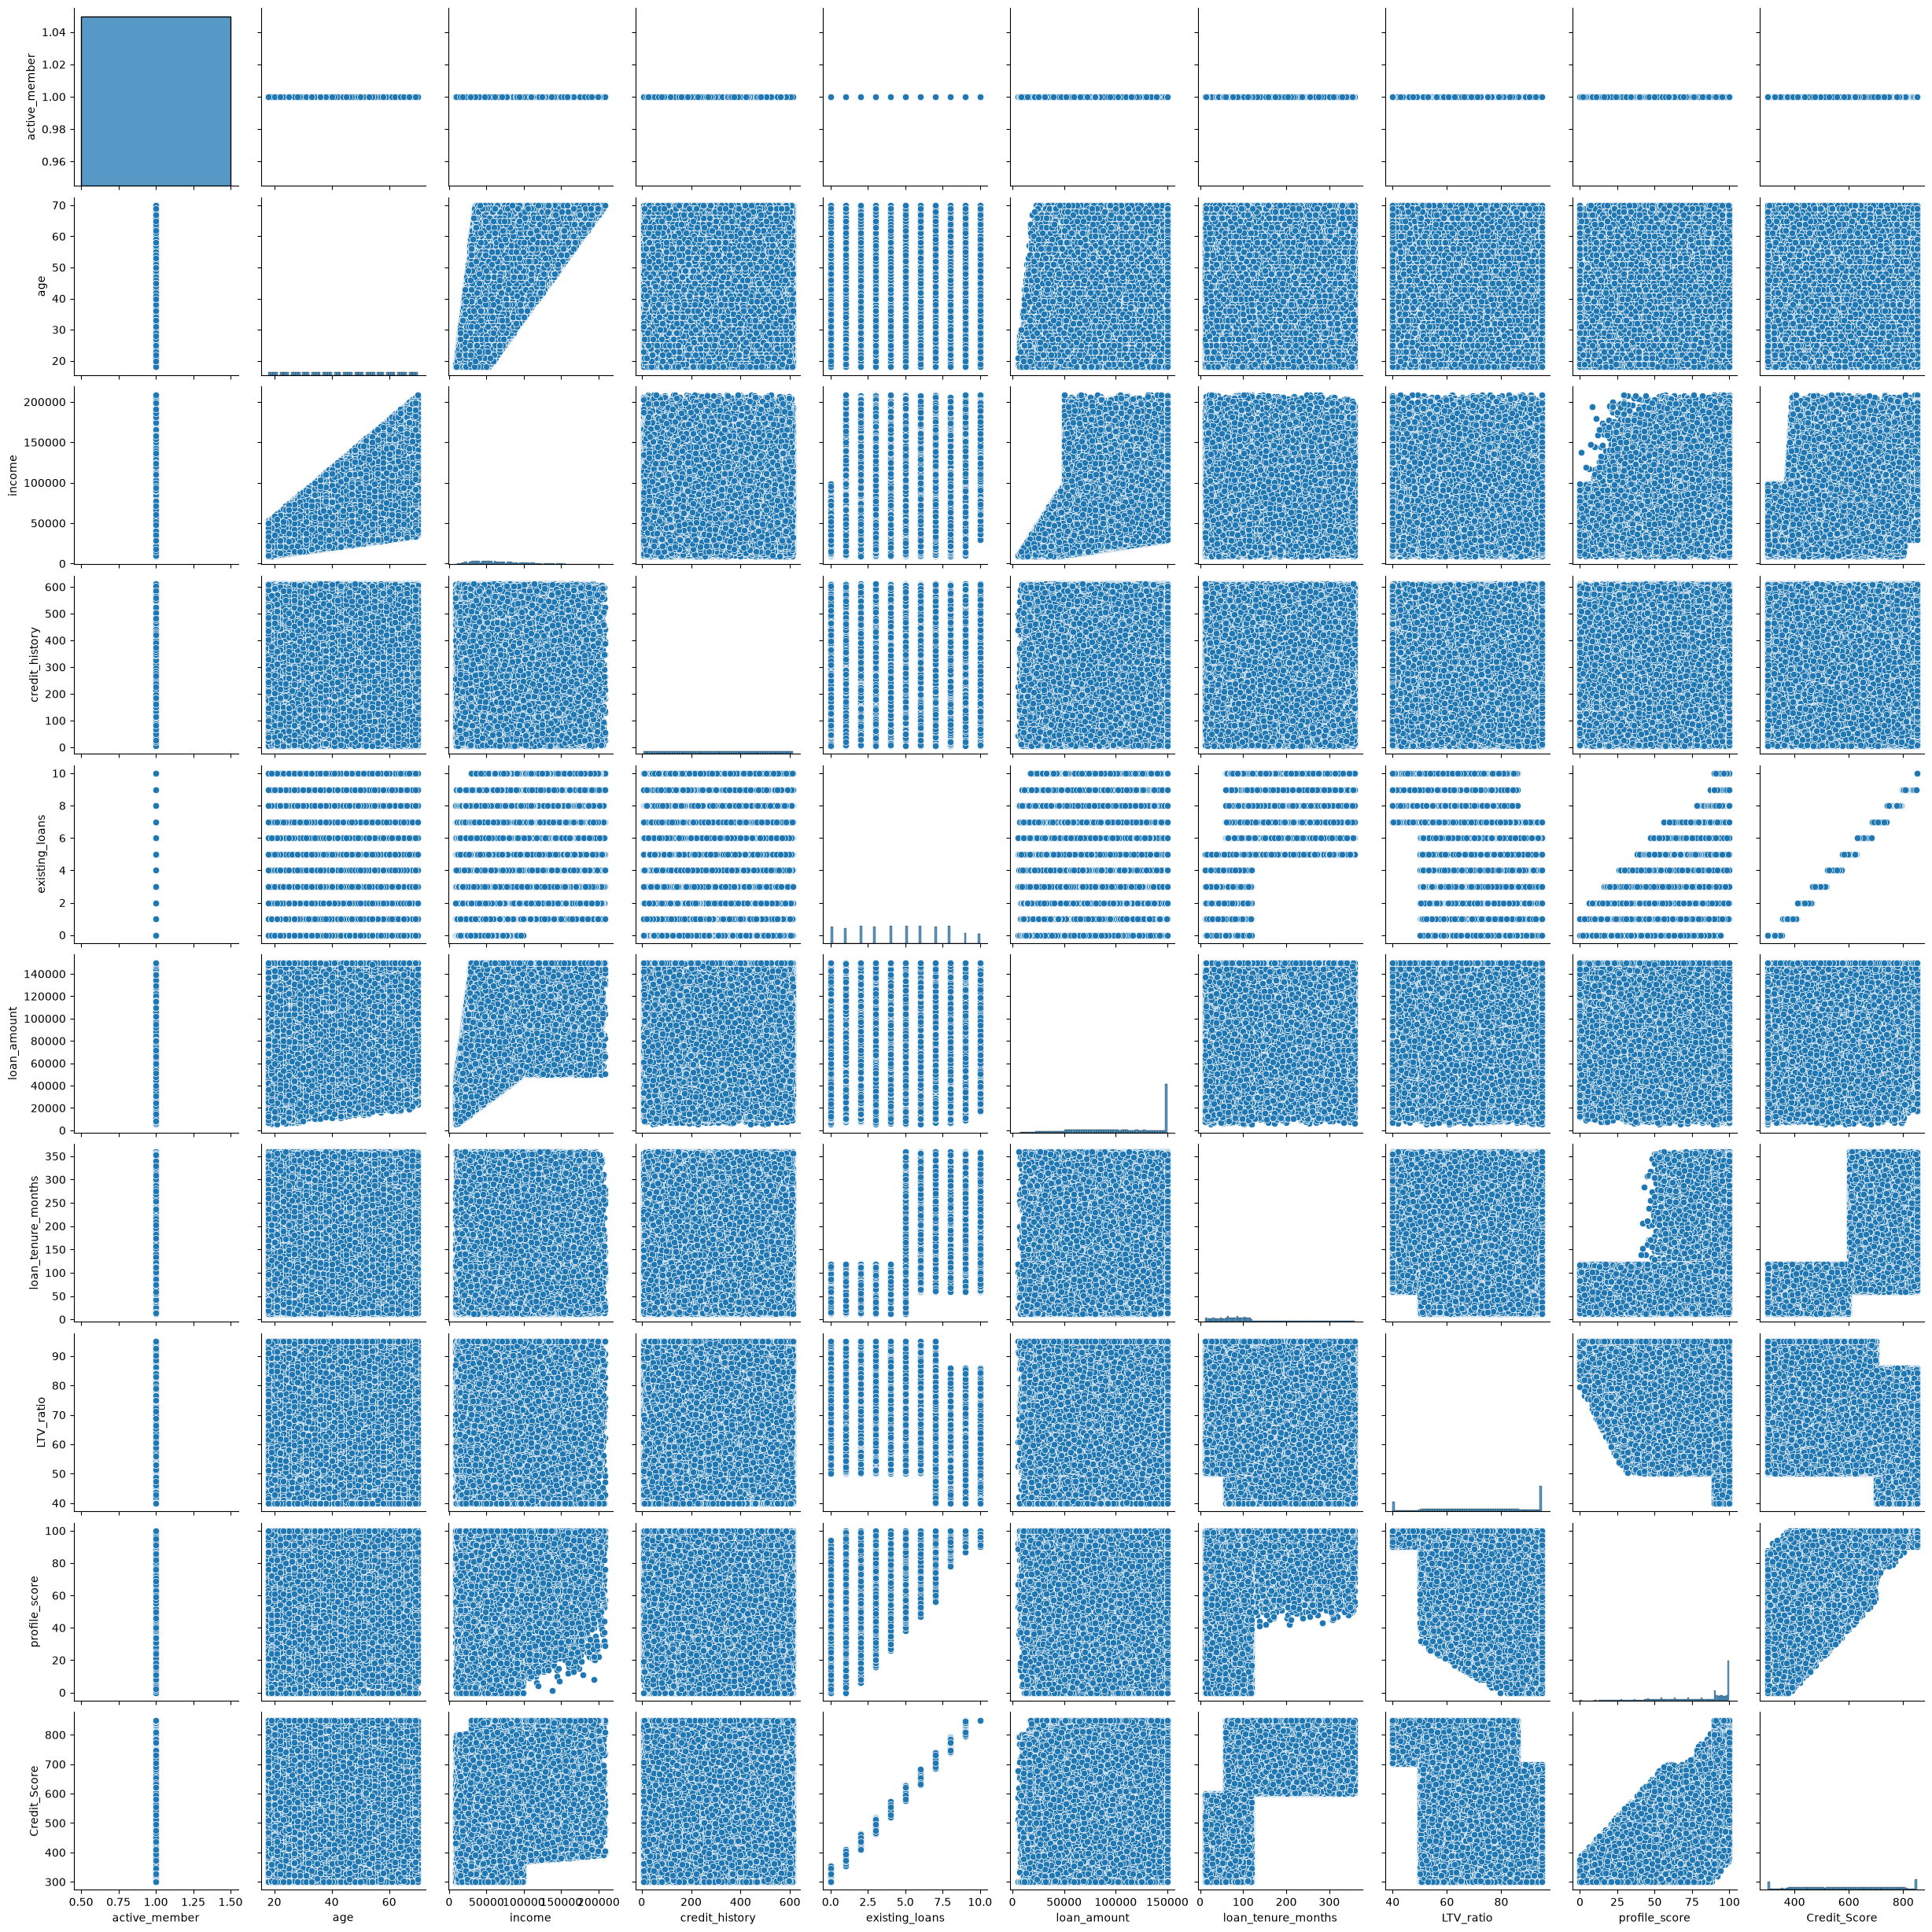

In [31]:
sns.pairplot(df)
plt.show()

/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25514/1329137164.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x = df['active_member'], y = df['Credit_Score'], palette = "Set2", edgecolor = "black", ax=axes[0,0])
/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25514/1329137164.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x = df['employment_profile'], y = df['Credit_Score'], palette = "Set2", edgecolor = "black", ax=axes[0,1])
/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25514/1329137164.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x = df['gender'], y = df['Credit_Score'], palette = "Set2", edgecolor = "black", ax=axes[0,2])
/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25514/1329137164.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.

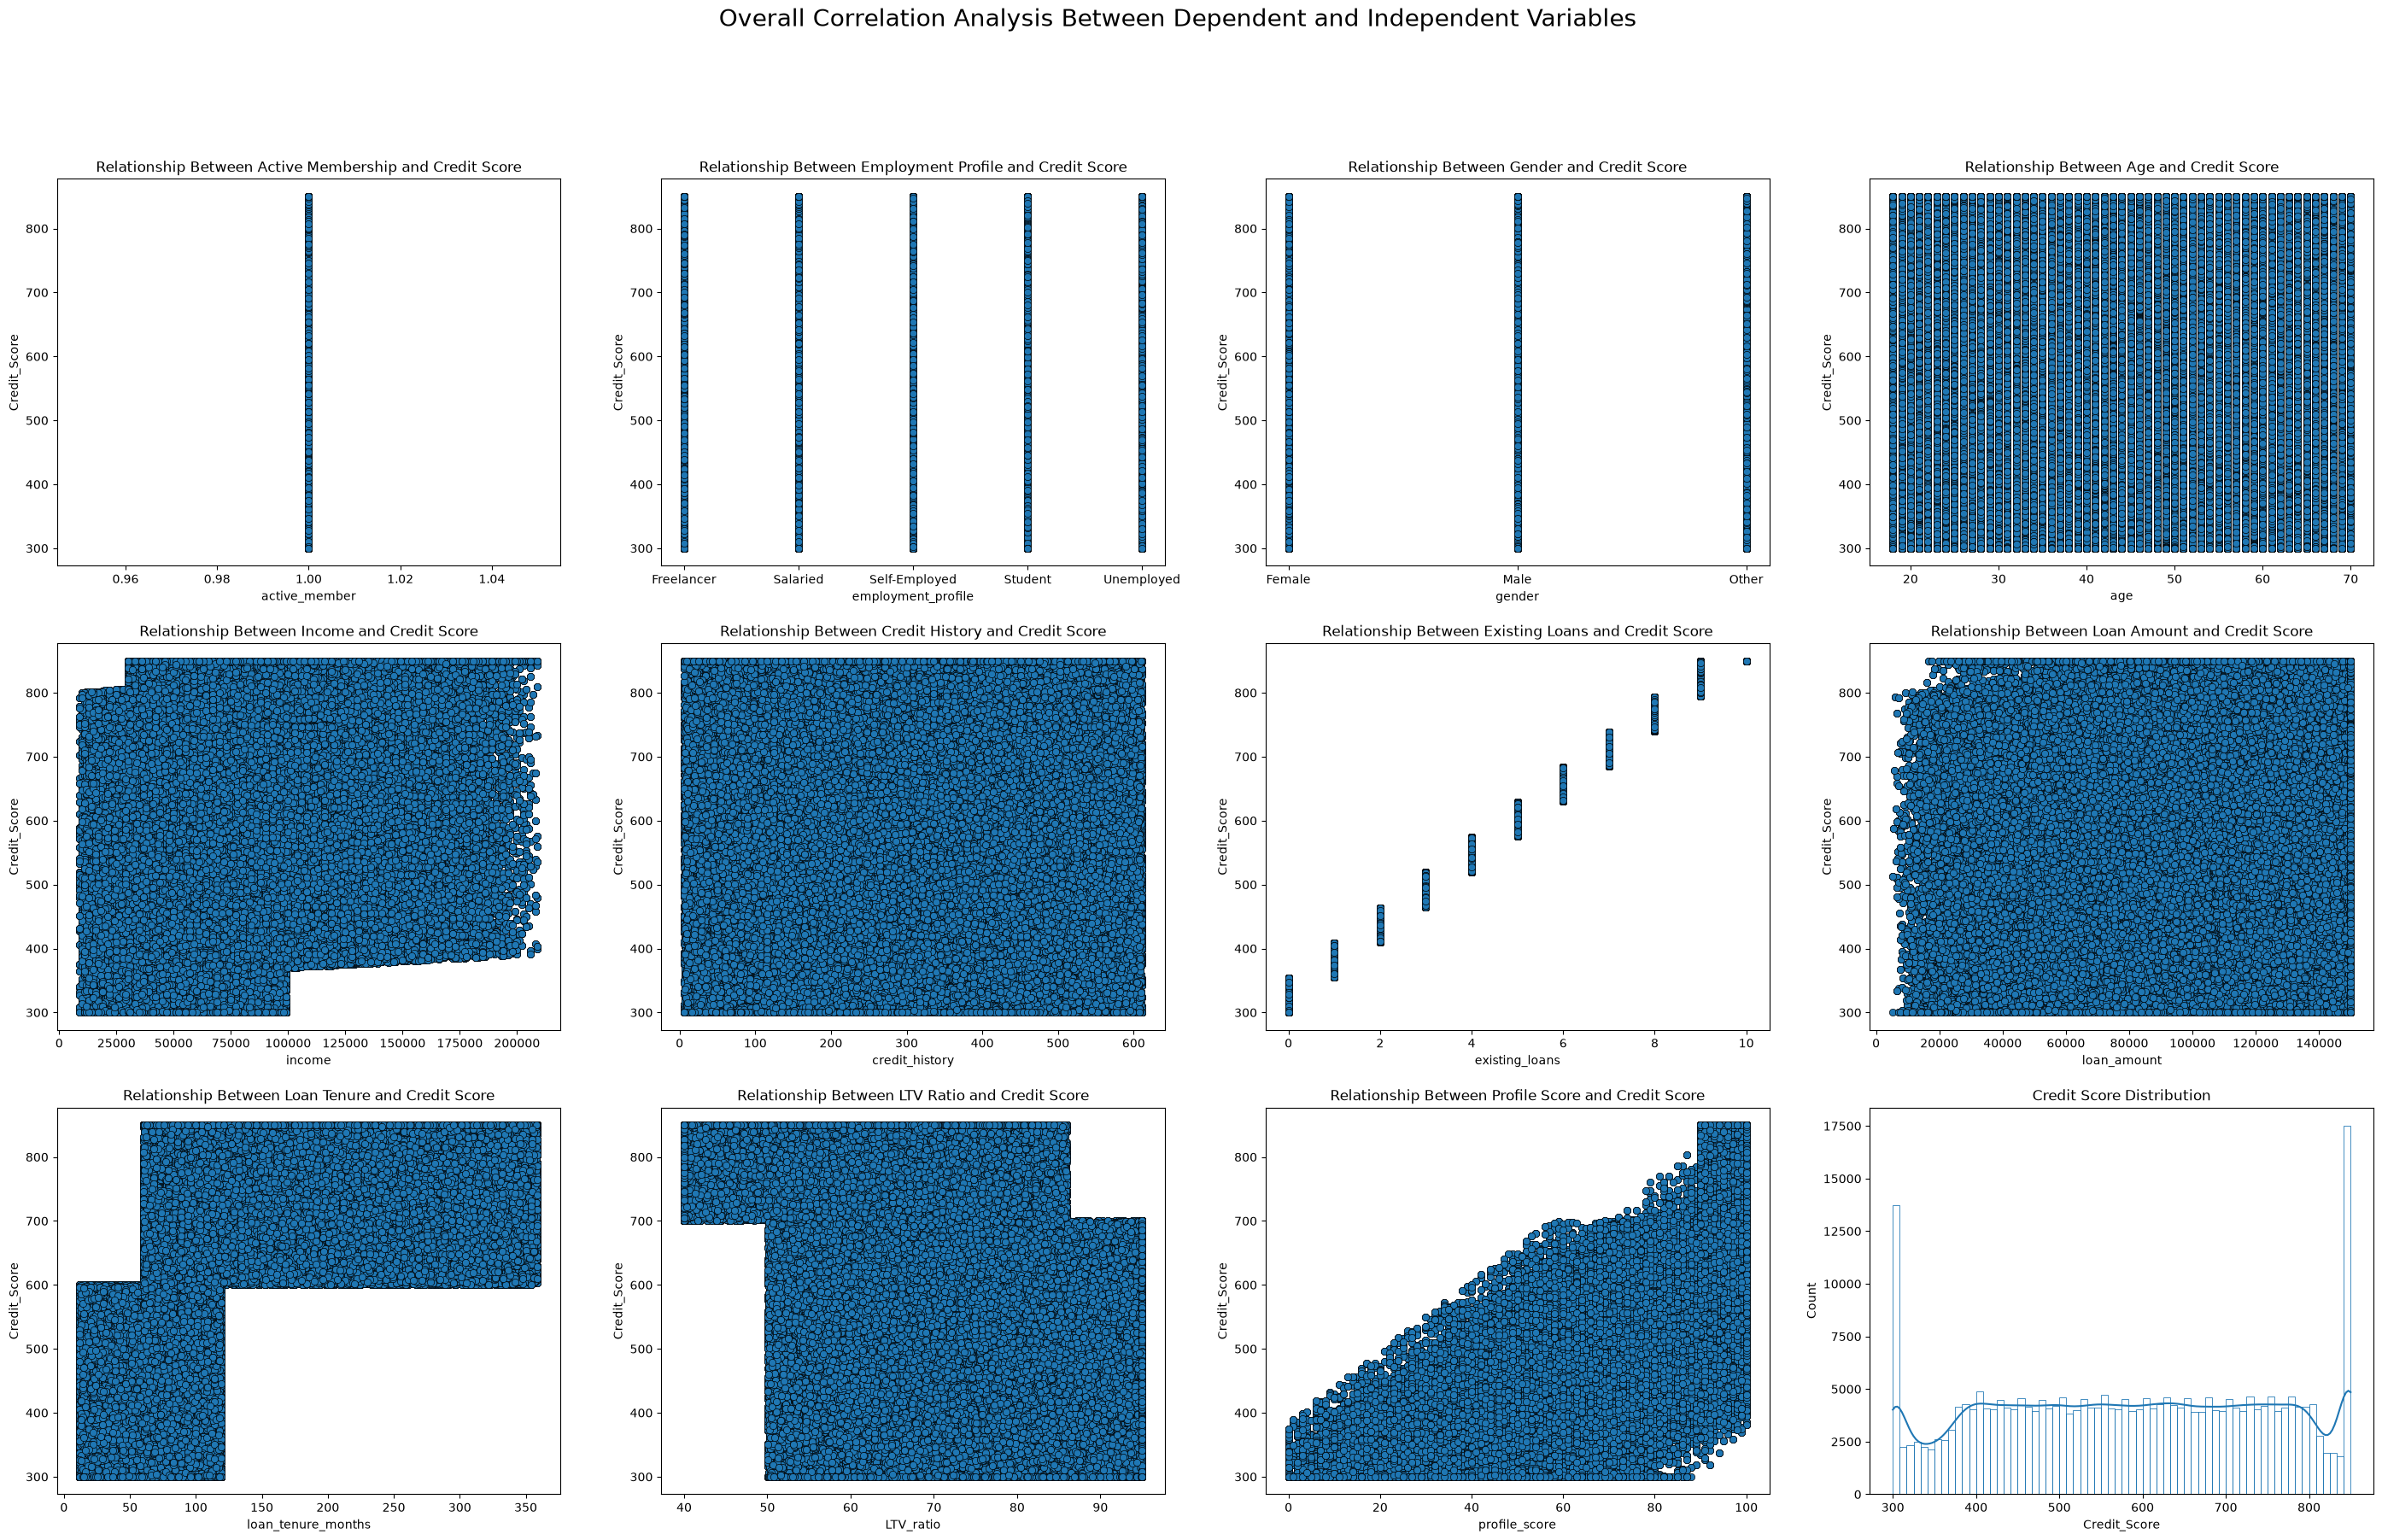

In [32]:
# Scatterplot between dependent and independent variables / Gráfico de dispersión entre variables dependientes e independientes

fig, axes = plt.subplots(3, 4, figsize=(35, 20))

sns.scatterplot(x = df['active_member'], y = df['Credit_Score'], palette = "Set2", edgecolor = "black", ax=axes[0,0])
sns.scatterplot(x = df['employment_profile'], y = df['Credit_Score'], palette = "Set2", edgecolor = "black", ax=axes[0,1])
sns.scatterplot(x = df['gender'], y = df['Credit_Score'], palette = "Set2", edgecolor = "black", ax=axes[0,2])
sns.scatterplot(x = df['age'], y = df['Credit_Score'], palette = "Set2", edgecolor = "black", ax=axes[0,3])
sns.scatterplot(x = df['income'], y = df['Credit_Score'], palette = "Set2", edgecolor = "black", ax=axes[1,0])
sns.scatterplot(x = df['credit_history'], y = df['Credit_Score'], palette = "Set2", edgecolor = "black", ax=axes[1,1])
sns.scatterplot(x = df['existing_loans'], y = df['Credit_Score'], palette = "Set2", edgecolor = "black", ax=axes[1,2])
sns.scatterplot(x = df['loan_amount'], y = df['Credit_Score'], palette = "Set2", edgecolor = "black", ax=axes[1,3])
sns.scatterplot(x = df['loan_tenure_months'], y = df['Credit_Score'], palette = "Set2", edgecolor = "black", ax=axes[2,0])
sns.scatterplot(x = df['LTV_ratio'], y = df['Credit_Score'], palette = "Set2", edgecolor = "black", ax=axes[2,1])
sns.scatterplot(x = df['profile_score'], y = df['Credit_Score'], palette = "Set2", edgecolor = "black", ax=axes[2,2])
sns.histplot(df['Credit_Score'], kde=True, fill = False, ax=axes[2,3])

axes[0,0].set(title='Relationship Between Active Membership and Credit Score')
axes[0,1].set(title='Relationship Between Employment Profile and Credit Score')
axes[0,2].set(title='Relationship Between Gender and Credit Score')
axes[0,3].set(title='Relationship Between Age and Credit Score')
axes[1,0].set(title='Relationship Between Income and Credit Score')
axes[1,1].set(title='Relationship Between Credit History and Credit Score')
axes[1,2].set(title='Relationship Between Existing Loans and Credit Score')
axes[1,3].set(title='Relationship Between Loan Amount and Credit Score')
axes[2,0].set(title='Relationship Between Loan Tenure and Credit Score')
axes[2,1].set(title='Relationship Between LTV Ratio and Credit Score')
axes[2,2].set(title='Relationship Between Profile Score and Credit Score')
axes[2,3].set(title='Credit Score Distribution')

fig.suptitle('Overall Correlation Analysis Between Dependent and Independent Variables', fontsize=20);

plt.show()

# Defining X and y / Definiendo X e y

In [33]:
df_modelo = df
df_modelo

,active_member,employment_profile,gender,age,income,credit_history,existing_loans,loan_amount,loan_tenure_months,LTV_ratio,profile_score,Credit_Score
0,True,Salaried,Male,31,36000,487,5,109373,221,90.943430,77,604
1,True,Salaried,Male,25,50000,386,2,150000,89,91.135253,43,447
2,True,Salaried,Other,62,178000,503,10,69099,110,40.000000,90,850
3,True,Self-Employed,Female,69,46000,349,6,150000,148,87.393365,86,668
4,True,Salaried,Male,52,132000,553,5,150000,157,66.158757,90,601
...,...,...,...,...,...,...,...,...,...,...,...,...
279851,True,Salaried,Male,69,61000,565,3,150000,14,90.300189,71,495
279852,True,Salaried,Female,45,124000,476,10,80341,86,78.960607,91,850
279853,True,Unemployed,Female,33,71000,560,5,39851,101,95.000000,57,582
279854,True,Salaried,Male,67,191000,481,2,150000,111,56.109002,69,411


## Encoding / Codificación

One Hot: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html

EN — Tutorial on using the One Hot Encoder class / ES — Tutorial sobre el uso de la clase One Hot Encoder: https://interactivechaos.com/es/manual/tutorial-de-machine-learning/la-clase-onehotencoder

In [34]:
# Create One Hot Encoder instance / Crear instancia de One Hot Encoder

encoder_gender = OneHotEncoder()
encoder_employment = OneHotEncoder()

In [35]:
# Apply transformation to the gender column / Aplicar la transformación a la columna de género

gender_cod = encoder_gender.fit_transform(df_modelo['gender'].values.reshape(-1, 1)).toarray()

In [36]:
# Add encoded gender columns to the dataset / Agregar las columnas de género codificadas al dataset

df_modelo = pd.concat([
    df_modelo.drop("gender", axis = 1),
    pd.DataFrame(gender_cod, columns=encoder_gender.get_feature_names_out(['gender']))
], axis = 1)




In [37]:
# Apply transformation to the employment profile column / Aplicar la transformación a la columna de perfil laboral

employment_profile_cod = encoder_gender.fit_transform(df_modelo['employment_profile'].values.reshape(-1, 1))
employment_profile_cod = employment_profile_cod.toarray()

In [38]:
# Add encoded employment profile columns to the dataset / Agregar las columnas de perfil laboral codificadas al dataset

df_modelo = pd.concat([
    df_modelo.drop("employment_profile", axis = 1),
    pd.DataFrame(employment_profile_cod, columns = encoder_gender.get_feature_names_out(['employment_profile']))
], axis = 1)

In [39]:
df_modelo

,active_member,age,income,credit_history,existing_loans,loan_amount,loan_tenure_months,LTV_ratio,profile_score,Credit_Score,gender_Female,gender_Male,gender_Other,employment_profile_Freelancer,employment_profile_Salaried,employment_profile_Self-Employed,employment_profile_Student,employment_profile_Unemployed
0,True,31,36000,487,5,109373,221,90.943430,77,604,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,True,25,50000,386,2,150000,89,91.135253,43,447,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,True,62,178000,503,10,69099,110,40.000000,90,850,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,True,69,46000,349,6,150000,148,87.393365,86,668,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,True,52,132000,553,5,150000,157,66.158757,90,601,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279851,True,69,61000,565,3,150000,14,90.300189,71,495,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
279852,True,45,124000,476,10,80341,86,78.960607,91,850,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
279853,True,33,71000,560,5,39851,101,95.000000,57,582,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
279854,True,67,191000,481,2,150000,111,56.109002,69,411,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


## Standardization / Estandarización

In [40]:
# MinMaxScaler documentation / Documentación de MinMaxScaler
#https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html
# MinMaxScaler rescales features to a [0, 1] range / MinMaxScaler reescala las variables a un rango [0, 1]

scaler = StandardScaler()

income_credithistory_existingloans_loanamount_loantenuremonths_ltv_profilescore = df_modelo[[ 'income', 'credit_history', 'existing_loans',
       'loan_amount', 'loan_tenure_months', 'LTV_ratio', 'profile_score']]

income_credithistory_existingloans_loanamount_loantenuremonths_ltv_profilescore = pd.DataFrame(scaler.fit_transform(income_credithistory_existingloans_loanamount_loantenuremonths_ltv_profilescore), columns=income_credithistory_existingloans_loanamount_loantenuremonths_ltv_profilescore.columns)
print(income_credithistory_existingloans_loanamount_loantenuremonths_ltv_profilescore)

df_modelo = df_modelo.drop([ 'income', 'credit_history', 'existing_loans',
       'loan_amount', 'loan_tenure_months', 'LTV_ratio', 'profile_score'],axis = 1)

df_modelo = pd.concat([income_credithistory_existingloans_loanamount_loantenuremonths_ltv_profilescore,df_modelo], axis = 1)

df_modelo

          income  credit_history  existing_loans  loan_amount  \
0      -0.944576        1.022572        0.100091     0.088428   
1      -0.618049        0.445702       -0.906503     1.092598   
2       2.367339        1.113957        1.777749    -0.907016   
3      -0.711342        0.234374        0.435623     1.092598   
4       1.294465        1.399536        0.100091     1.092598   
...          ...             ...             ...          ...   
279851 -0.361492        1.468075       -0.570972     1.092598   
279852  1.107878        0.959744        1.777749    -0.629150   
279853 -0.128259        1.439517        0.100091    -1.629934   
279854  2.670542        0.988302       -0.906503     1.092598   
279855 -1.364396        0.377163       -0.570972    -1.341464   

        loan_tenure_months  LTV_ratio  profile_score  
0                 0.912510   1.144350      -0.014287  
1                -0.461574   1.155724      -1.401524  
2                -0.242970  -1.876175       0.516127  

,income,credit_history,existing_loans,loan_amount,loan_tenure_months,LTV_ratio,profile_score,active_member,age,Credit_Score,gender_Female,gender_Male,gender_Other,employment_profile_Freelancer,employment_profile_Salaried,employment_profile_Self-Employed,employment_profile_Student,employment_profile_Unemployed
0,-0.944576,1.022572,0.100091,0.088428,0.912510,1.144350,-0.014287,True,31,604,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.618049,0.445702,-0.906503,1.092598,-0.461574,1.155724,-1.401524,True,25,447,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,2.367339,1.113957,1.777749,-0.907016,-0.242970,-1.876175,0.516127,True,62,850,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,-0.711342,0.234374,0.435623,1.092598,0.152600,0.933861,0.352923,True,69,668,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.294465,1.399536,0.100091,1.092598,0.246287,-0.325176,0.516127,True,52,601,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279851,-0.361492,1.468075,-0.570972,1.092598,-1.242304,1.106211,-0.259093,True,69,495,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
279852,1.107878,0.959744,1.777749,-0.629150,-0.492803,0.433868,0.556928,True,45,850,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
279853,-0.128259,1.439517,0.100091,-1.629934,-0.336658,1.384871,-0.830308,True,33,582,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
279854,2.670542,0.988302,-0.906503,1.092598,-0.232560,-0.921044,-0.340695,True,67,411,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


## Dependent and Independent Variables / Variables Dependientes e Independientes

In [41]:
X = df_modelo.drop(['Credit_Score'],axis = 1)
print(X.shape)
print(X.head())

(279856, 17)
     income  credit_history  existing_loans  loan_amount  loan_tenure_months  \
0 -0.944576        1.022572        0.100091     0.088428            0.912510   
1 -0.618049        0.445702       -0.906503     1.092598           -0.461574   
2  2.367339        1.113957        1.777749    -0.907016           -0.242970   
3 -0.711342        0.234374        0.435623     1.092598            0.152600   
4  1.294465        1.399536        0.100091     1.092598            0.246287   

   LTV_ratio  profile_score  active_member  age  gender_Female  gender_Male  \
0   1.144350      -0.014287           True   31            0.0          1.0   
1   1.155724      -1.401524           True   25            0.0          1.0   
2  -1.876175       0.516127           True   62            0.0          0.0   
3   0.933861       0.352923           True   69            1.0          0.0   
4  -0.325176       0.516127           True   52            0.0          1.0   

   gender_Other  employment_pro

In [42]:
y = df_modelo['Credit_Score']
print(y.shape)
print(y.head())

(279856,)
0    604
1    447
2    850
3    668
4    601
Name: Credit_Score, dtype: int64


## Training and Test Data / Datos de Entrenamiento y Prueba

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(195899, 17)
(83957, 17)
(195899,)
(83957,)


## Data Modeling / Modelado de Datos

### LINEAR REGRESSION / REGRESIÓN LINEAL

In [44]:
# Train the model / Entrenar el modelo
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](17,)","[ 0.43, 0.02,155.54,..., -0.53, 1.7 , 1.73]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](17,)","['income','credit_history','existing_loans',..., 'employment_profile_Self-Employed','employment_profile_Student', 'employment_profile_Unemployed']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,584
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,17
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)


In [45]:
# Make predictions / Realizar predicciones

y_pred_lin = lin_reg.predict(X_test)


In [46]:
# Calculate metrics / Calcular métricas

mse_lin = mean_squared_error(y_test, y_pred_lin)
print(f"Mean Squared Error (Linear Regression): {mse_lin}")

rmse_lin = np.sqrt(mse_lin)
print(f"Root Mean Squared Error (Linear Regression): {rmse_lin}")

mae_lin = mean_absolute_error(y_test, y_pred_lin)
print(f"Mean Absolute Error (Linear Regression): {mae_lin}")

r2_lin = r2_score(y_test, y_pred_lin)
print(f"R-squared (Linear Regression): {r2_lin}")

Mean Squared Error (Linear Regression): 267.2383608340002
Root Mean Squared Error (Linear Regression): 16.34742673432122
Mean Absolute Error (Linear Regression): 14.056287973771736
R-squared (Linear Regression): 0.9899617136907473


In [47]:
resultado_rlin = pd.concat([pd.DataFrame(y_test).reset_index(drop=True), pd.DataFrame(y_pred_lin).reset_index(drop=True)], axis=1)
resultado_rlin.columns = ['Valor Real de Credit Score', 'Valor de Prediccion']
resultado_rlin

,Valor Real de Credit Score,Valor de Prediccion
0,786,761.413632
1,430,433.039289
2,814,815.904375
3,422,436.500323
4,617,601.406739
...,...,...
83952,655,661.425520
83953,811,815.461899
83954,362,373.246539
83955,578,604.574266


### K-Nearest Neighbors (KNN) / K Vecinos Más Cercanos (KNN)

In [48]:
knn_regressor = KNeighborsRegressor(n_neighbors=3)  # Usa 5 vecinos, pero puedes ajustarlo / Uses 5 neighbors, but you can adjust it
knn_regressor.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [49]:
y_pred_knn = knn_regressor.predict(X_test)

In [50]:
# Calculate metrics / Calcular métricas

mse_knn = mean_squared_error(y_test, y_pred_knn)
print(f"Mean Squared Error (Linear Regression): {mse_knn}")

rmse_knn = np.sqrt(mse_knn)
print(f"Root Mean Squared Error (Linear Regression): {rmse_knn}")

mae_knn = mean_absolute_error(y_test, y_pred_knn)
print(f"Mean Absolute Error (Linear Regression): {mae_knn}")

r2_knn = r2_score(y_test, y_pred_knn)
print(f"R-squared (Linear Regression): {r2_knn}")

Mean Squared Error (Linear Regression): 1404.8751583151693
Root Mean Squared Error (Linear Regression): 37.4816642948945
Mean Absolute Error (Linear Regression): 28.725319707310494
R-squared (Linear Regression): 0.9472286125992051


In [51]:
resultado_knn = pd.concat([pd.DataFrame(y_test).reset_index(drop=True), pd.DataFrame(y_pred_knn).reset_index(drop=True)], axis=1)
resultado_knn.columns = ['Valor Real de Credit Score', 'Valor de Prediccion']
resultado_knn

,Valor Real de Credit Score,Valor de Prediccion
0,786,768.666667
1,430,414.333333
2,814,834.666667
3,422,460.000000
4,617,637.666667
...,...,...
83952,655,686.000000
83953,811,823.333333
83954,362,323.333333
83955,578,659.333333


## Decision Tree / Árbol de Decisión

In [52]:
dt_regressor = DecisionTreeRegressor(random_state=0)


In [53]:
dt_regressor.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes m

In [54]:
y_pred_dt = dt_regressor.predict(X_test)

In [55]:
# Calculate metrics / Calcular métricas

mse_dt = mean_squared_error(y_test, y_pred_dt)
print(f"Mean Squared Error (Linear Regression): {mse_dt}")

rmse_dt = np.sqrt(mse_dt)
print(f"Root Mean Squared Error (Linear Regression): {rmse_dt}")

mae_dt = mean_absolute_error(y_test, y_pred_dt)
print(f"Mean Absolute Error (Linear Regression): {mae_dt}")

r2_dt = r2_score(y_test, y_pred_dt)
print(f"R-squared (Linear Regression): {r2_dt}")

Mean Squared Error (Linear Regression): 54.59414938599521
Root Mean Squared Error (Linear Regression): 7.388785379613838
Mean Absolute Error (Linear Regression): 2.1064949914837356
R-squared (Linear Regression): 0.9979492775639079


In [56]:
resultado_dt = pd.concat([pd.DataFrame(y_test).reset_index(drop=True), pd.DataFrame(y_pred_dt).reset_index(drop=True)], axis=1)
resultado_dt.columns = ['Valor Real de Credit Score', 'Valor de Prediccion']
resultado_dt

,Valor Real de Credit Score,Valor de Prediccion
0,786,786.0
1,430,451.0
2,814,814.0
3,422,422.0
4,617,622.0
...,...,...
83952,655,655.0
83953,811,811.0
83954,362,362.0
83955,578,578.0
